# Exploring the signals of music genres
Run the cells in order, or run `python src/explore_features.py` from the project
folder. This analysis reads the extracted features; it never loads audio again.
Data checks cover all splits, while distributions, correlations and feature
rankings use **training tracks only**. Validation and test features stay held out.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_dir():
    """Work from the project root, notebooks folder, or the standalone script."""
    start = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
    for candidate in (start, *start.parents):
        if (candidate / "outputs" / "features.csv").is_file():
            return candidate
    raise FileNotFoundError("Cannot find outputs/features.csv. Open this project's folder first.")


PROJECT_DIR = find_project_dir()
OUTPUT_DIR = PROJECT_DIR / "outputs" / "eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False})
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 140)


def show_table(table):
    """Readable output in both a notebook and a terminal."""
    try:
        from IPython.display import display
        if get_ipython() is not None:
            display(table)
            return
    except (ImportError, NameError):
        pass
    print(table.to_string())


def save_plot(fig, filename):
    fig.savefig(OUTPUT_DIR / filename, dpi=160, bbox_inches="tight")
    if "__file__" not in globals() or plt.get_backend().lower() != "agg":
        plt.show()
    plt.close(fig)


features = pd.read_csv(PROJECT_DIR / "outputs" / "features.csv")
audit = pd.read_csv(PROJECT_DIR / "outputs" / "dataset_audit.csv")
error_path = PROJECT_DIR / "outputs" / "extraction_errors.csv"
errors = (pd.read_csv(error_path) if error_path.exists()
          else pd.DataFrame(columns=["track_id", "error"]))
metadata_columns = ["track_id", "genre", "split"]
feature_columns = ["tempo"]
for name in ["rms", "zcr", "centroid", "bandwidth", "rolloff", "flatness", "chroma"]:
    feature_columns.extend([f"{name}_mean", f"{name}_std"])
for number in range(1, 14):
    feature_columns.extend([f"mfcc_{number}_mean", f"mfcc_{number}_std"])

expected_columns = set(metadata_columns + feature_columns)
if set(features.columns) != expected_columns:
    raise ValueError(f"Unexpected feature schema. Missing: {expected_columns - set(features.columns)}; "
                     f"extra: {set(features.columns) - expected_columns}")
if features.empty:
    raise ValueError("The feature file is empty. Finish extraction before continuing.")
print(f"Loaded {len(features):,} tracks and {len(feature_columns)} audio features.")


Loaded 7,994 tracks and 41 audio features.


## 1. Validate the extraction
Missing values, infinity and duplicate track IDs are different problems, so we
check each separately. Track IDs, genre labels and split assignments must match
the audit. Checks stop the analysis if the data needs attention; no rows are
silently dropped or imputed.

In [2]:
numeric = features[feature_columns].apply(pd.to_numeric, errors="raise")
checks = pd.Series({
    "Missing cells": int(features.isna().sum().sum()),
    "Infinite feature values": int(np.isinf(numeric.to_numpy()).sum()),
    "Duplicate feature track IDs": int(features.track_id.duplicated().sum()),
    "Duplicate audit track IDs": int(audit.track_id.duplicated().sum()),
    "Duplicate error track IDs": int(errors.track_id.duplicated().sum()),
    "Unknown split labels": int((~features.split.isin(["training", "validation", "test"])).sum()),
}, name="count")
show_table(checks.to_frame())
if checks.sum() != 0:
    raise ValueError("Resolve the nonzero data checks above before exploring features.")

joined = features[metadata_columns].merge(
    audit[metadata_columns], on="track_id", how="left", suffixes=("", "_audit"),
    validate="one_to_one", indicator=True,
)
bad_metadata = joined[(joined["_merge"] != "both")
                      | (joined.genre != joined.genre_audit)
                      | (joined.split != joined.split_audit)]
if not bad_metadata.empty:
    show_table(bad_metadata)
    raise ValueError("Some extracted tracks do not match the dataset audit.")

available = audit[audit["exists"].astype(str).str.lower().eq("true")].copy()
missing_tracks = available[~available.track_id.isin(features.track_id)].copy()
if not set(features.track_id).issubset(set(available.track_id)):
    raise ValueError("Extracted tracks include IDs not marked available in the audit.")
if set(missing_tracks.track_id) != set(errors.track_id):
    raise ValueError("The missing track IDs do not match the error log. Check for a partial run or stale log.")
print(f"Reconciled: {len(available):,} attempted = {len(features):,} extracted + {len(errors)} failed.")


                             count
Missing cells                    0
Infinite feature values          0
Duplicate feature track IDs      0
Duplicate audit track IDs        0
Duplicate error track IDs        0
Unknown split labels             0
Reconciled: 8,000 attempted = 7,994 extracted + 6 failed.


## 2. Document failed tracks and split sizes
An error message records what the loader reported, not a confirmed root cause.
A file-access error could need a fresh filesystem check; a decoder error may
need an individual retry. You can continue this analysis with documented failures.
Counts below are a structural check, not an exploration of held-out features.

In [3]:
failure_details = missing_tracks[["track_id", "genre", "split"]].merge(
    errors, on="track_id", how="left", validate="one_to_one",
)
if failure_details.empty:
    print("No failed tracks.")
else:
    show_table(failure_details)
    print("\nFull error messages:")
    for row in failure_details.itertuples(index=False):
        print(f"{row.track_id} ({row.genre}, {row.split}): {row.error}")

split_order = ["training", "validation", "test"]
split_counts = pd.crosstab(features.genre, features.split).reindex(columns=split_order, fill_value=0)
split_counts["total"] = split_counts.sum(axis=1)
show_table(split_counts)


   track_id         genre     split                                                                                                                                                                                                         error
0     98565       Hip-Hop  training                                                                                                                                                                                   Unspecified internal error.
1     98567       Hip-Hop  training                                                                                                                                                                                   Unspecified internal error.
2     98569       Hip-Hop  training                                                                                                                                                                                   Unspecified internal error.
3     99134    Electronic  train

## 3. Explore the training set
Each row describes one track using up to 30 seconds of audio. The `_mean` and
`_std` features summarize measurements over the clip (chroma also pools pitch
classes). These summaries do not retain the complete musical structure.

- **Tempo:** estimated beats per minute; half/double-time estimates can occur.
- **RMS:** signal amplitude/energy proxy, not a calibrated perceived-loudness measure.
- **Spectral centroid:** frequency-weighted center of the spectrum, in Hz.
- **Zero-crossing rate:** fraction of waveform sign changes per analysis frame.
- **MFCCs:** numerical summaries of spectral shape, useful for describing timbre.

In [4]:
train = features.loc[features.split.eq("training")].copy()
if train.empty or train.genre.nunique() < 2:
    raise ValueError("Need a nonempty training split containing at least two genres.")
genres = sorted(train.genre.unique())
constant_features = train[feature_columns].columns[train[feature_columns].nunique() <= 1].tolist()
print(f"All feature exploration below uses {len(train):,} training tracks across {len(genres)} genres.")
print(f"Constant training features: {constant_features or 'none'}")
key_features = ["tempo", "rms_mean", "centroid_mean", "zcr_mean"]
show_table(train[key_features].describe().T.round(4))
show_table(train.groupby("genre")[key_features].median().round(4))


All feature exploration below uses 6,394 training tracks across 8 genres.
Constant training features: none
                count       mean       std      min        25%        50%        75%        max
tempo          6394.0   122.3648   21.3694  45.3331   107.6660   123.0469   135.9992   215.3320
rms_mean       6394.0     0.1782    0.0962   0.0000     0.1057     0.1672     0.2369     0.8724
centroid_mean  6394.0  1906.5095  722.8486   0.0000  1395.3919  1893.4520  2378.4769  6765.7466
zcr_mean       6394.0     0.0848    0.0455   0.0000     0.0532     0.0772     0.1064     0.6270
                  tempo  rms_mean  centroid_mean  zcr_mean
genre                                                     
Electronic     123.0469    0.2155      2169.4825    0.0766
Experimental   123.0469    0.1298      1742.0613    0.0767
Folk           123.0469    0.1396      1462.0151    0.0574
Hip-Hop        107.6660    0.2229      2309.0551    0.0901
Instrumental   117.4538    0.1105      1050.8028    0.0492


### Compare distributions, not just averages
Each box spans the middle 50% of tracks; the line marks the median. Whiskers
extend to the most extreme points within 1.5 times the interquartile range.
Outliers are hidden on this plot for readability but remain in every calculation.
Heavy overlap means a feature alone is unlikely to separate the genres well.

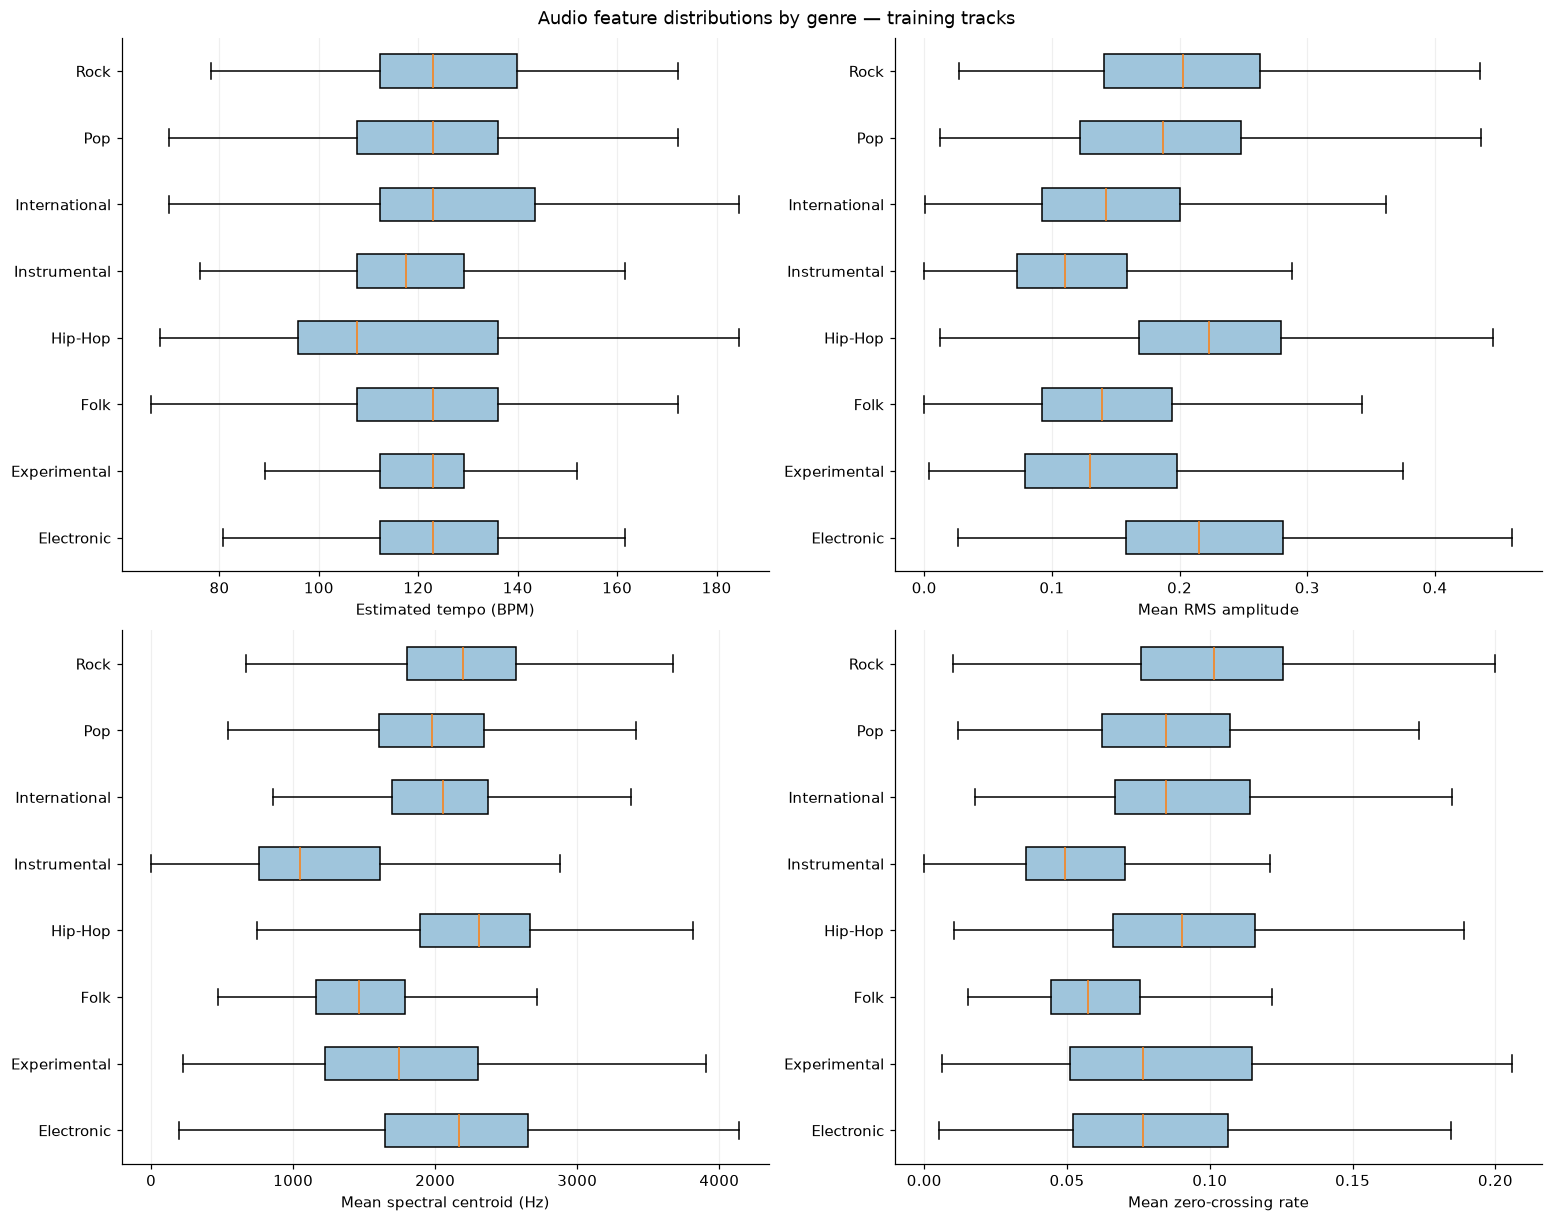

In [5]:
labels = {"tempo": "Estimated tempo (BPM)", "rms_mean": "Mean RMS amplitude",
          "centroid_mean": "Mean spectral centroid (Hz)", "zcr_mean": "Mean zero-crossing rate"}
fig, axes = plt.subplots(2, 2, figsize=(14, 11), constrained_layout=True)
for ax, feature in zip(axes.flat, key_features):
    values = [train.loc[train.genre.eq(genre), feature].to_numpy() for genre in genres]
    boxes = ax.boxplot(values, orientation="horizontal", patch_artist=True, showfliers=False)
    for box in boxes["boxes"]:
        box.set_facecolor("#9fc5dc")
    ax.set_yticks(range(1, len(genres) + 1), labels=genres)
    ax.set_xlabel(labels[feature])
    ax.grid(axis="x", alpha=0.2)
fig.suptitle("Audio feature distributions by genre — training tracks")
save_plot(fig, "genre_distributions.png")


## 4. Which features differ most across genres?
Eta-squared is the between-genre sum of squares divided by the total sum of
squares. It lies between 0 and 1: larger values mean genre group means explain
more of the observed feature variation **in this training sample**. It measures
one feature at a time, not classifier accuracy, causation or test performance.
No significance tests are used. Constant features have an undefined score.

                eta_squared
bandwidth_mean       0.2518
rolloff_mean         0.2409
chroma_mean          0.2401
centroid_std         0.2363
mfcc_1_mean          0.2359
centroid_mean        0.2167
mfcc_2_mean          0.1951
rms_std              0.1920
rolloff_std          0.1865
zcr_std              0.1813
rms_mean             0.1369
flatness_std         0.1317
mfcc_12_mean         0.1277
mfcc_5_std           0.1233
mfcc_10_mean         0.1228


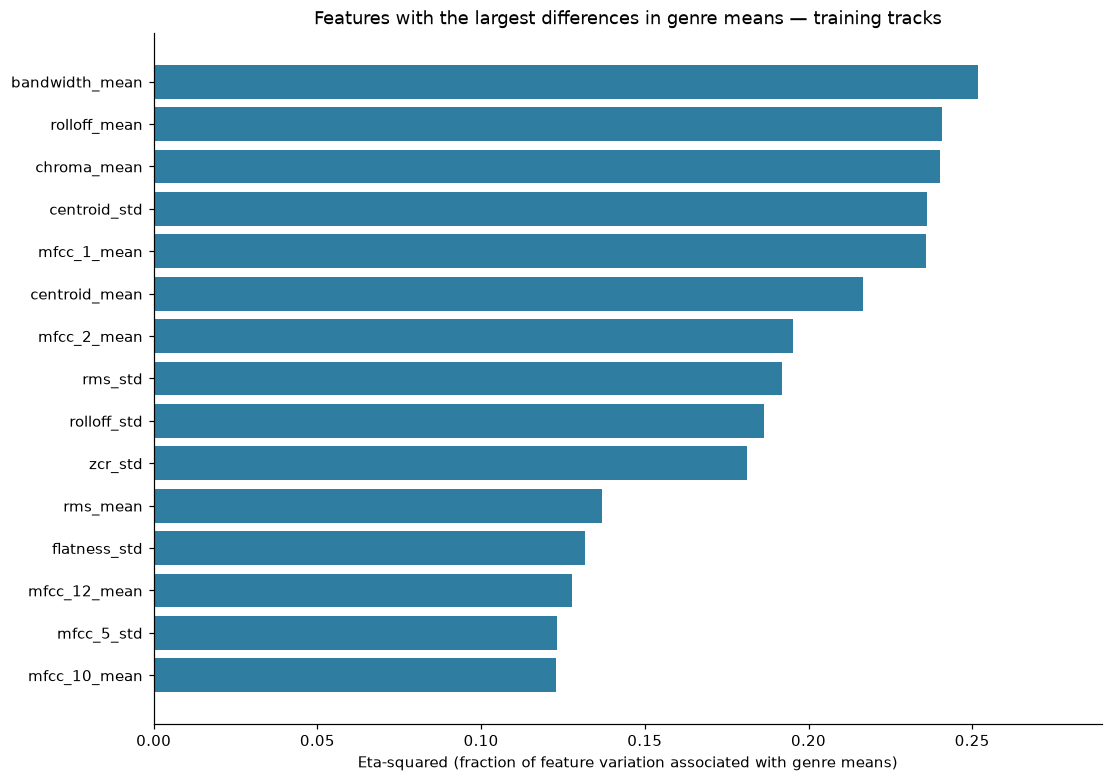

In [6]:
values = train[feature_columns]
grand_means = values.mean()
group_means = train.groupby("genre")[feature_columns].mean()
group_sizes = train.groupby("genre").size()
between_ss = group_means.sub(grand_means).pow(2).mul(group_sizes, axis=0).sum()
total_ss = values.sub(grand_means).pow(2).sum()
ranking = (between_ss / total_ss.replace(0, np.nan)).rename("eta_squared").sort_values(ascending=False).to_frame()
show_table(ranking.head(15).round(4))

fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
top = ranking.dropna().head(15).iloc[::-1]
ax.barh(top.index, top.eta_squared, color="#307da2")
ax.set_xlabel("Eta-squared (fraction of feature variation associated with genre means)")
ax.set_title("Features with the largest differences in genre means — training tracks")
ax.set_xlim(0, max(0.1, float(top.eta_squared.max()) * 1.15))
save_plot(fig, "feature_genre_association.png")


### Compare genre profiles on a common scale
These are genre medians after standardizing each feature with the training
mean and standard deviation. Red is above the training mean; blue is below.
Standardization here supports plotting only; a future classifier should fit its
own preprocessing on training data in a pipeline.

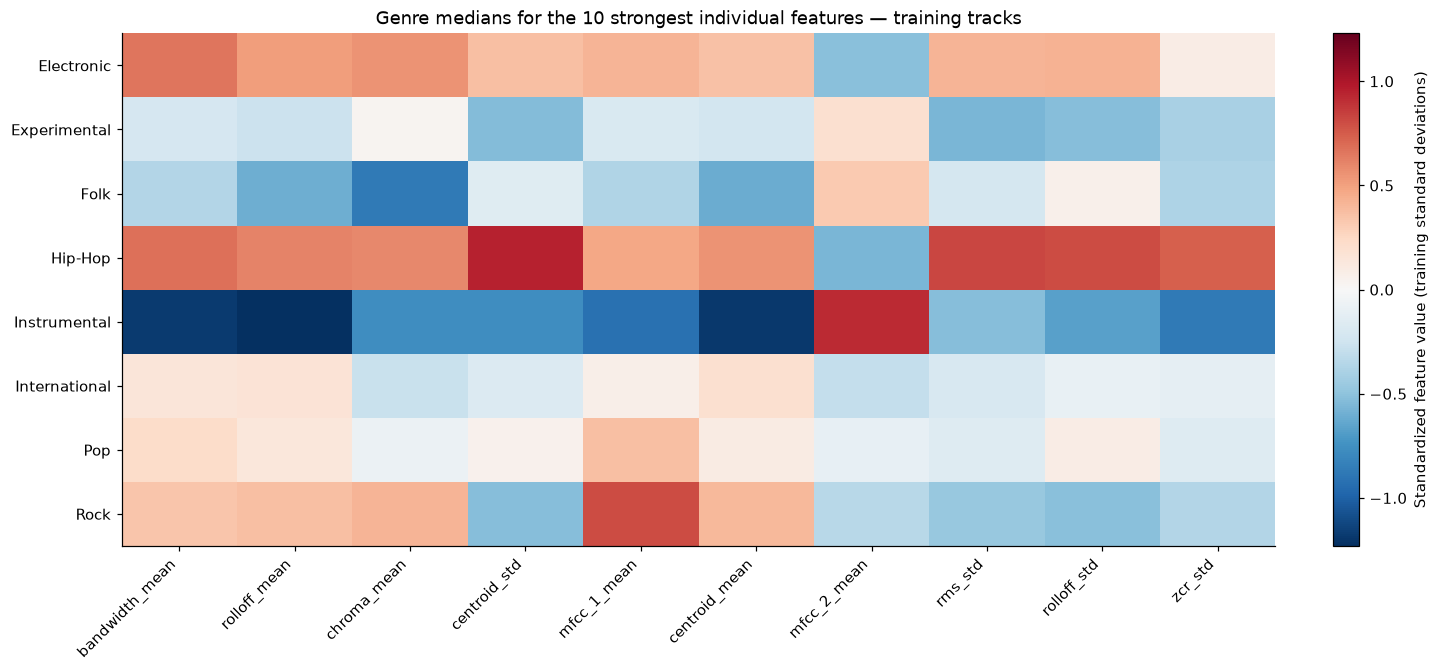

In [7]:
top_features = ranking.dropna().head(10).index.tolist()
standardized = values[top_features].sub(values[top_features].mean()).div(values[top_features].std(ddof=0))
profiles = standardized.groupby(train.genre).median().reindex(genres)
fig, ax = plt.subplots(figsize=(13, 6), constrained_layout=True)
limit = max(float(np.abs(profiles.to_numpy()).max()), 0.1)
heat = ax.imshow(profiles, cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
ax.set_xticks(range(len(top_features)), labels=top_features, rotation=45, ha="right")
ax.set_yticks(range(len(genres)), labels=genres)
ax.set_title("Genre medians for the 10 strongest individual features — training tracks")
fig.colorbar(heat, ax=ax, label="Standardized feature value (training standard deviations)")
save_plot(fig, "genre_profiles.png")


## 5. Find correlated measurements
Pearson correlation measures linear relationships between features. Values near
+1 or -1 indicate strong relationships. This can identify redundant inputs,
but does not automatically mean one should be removed. The threshold of 0.90
below is a review aid. Constant features are excluded because their correlation
is undefined; each pair is listed once.

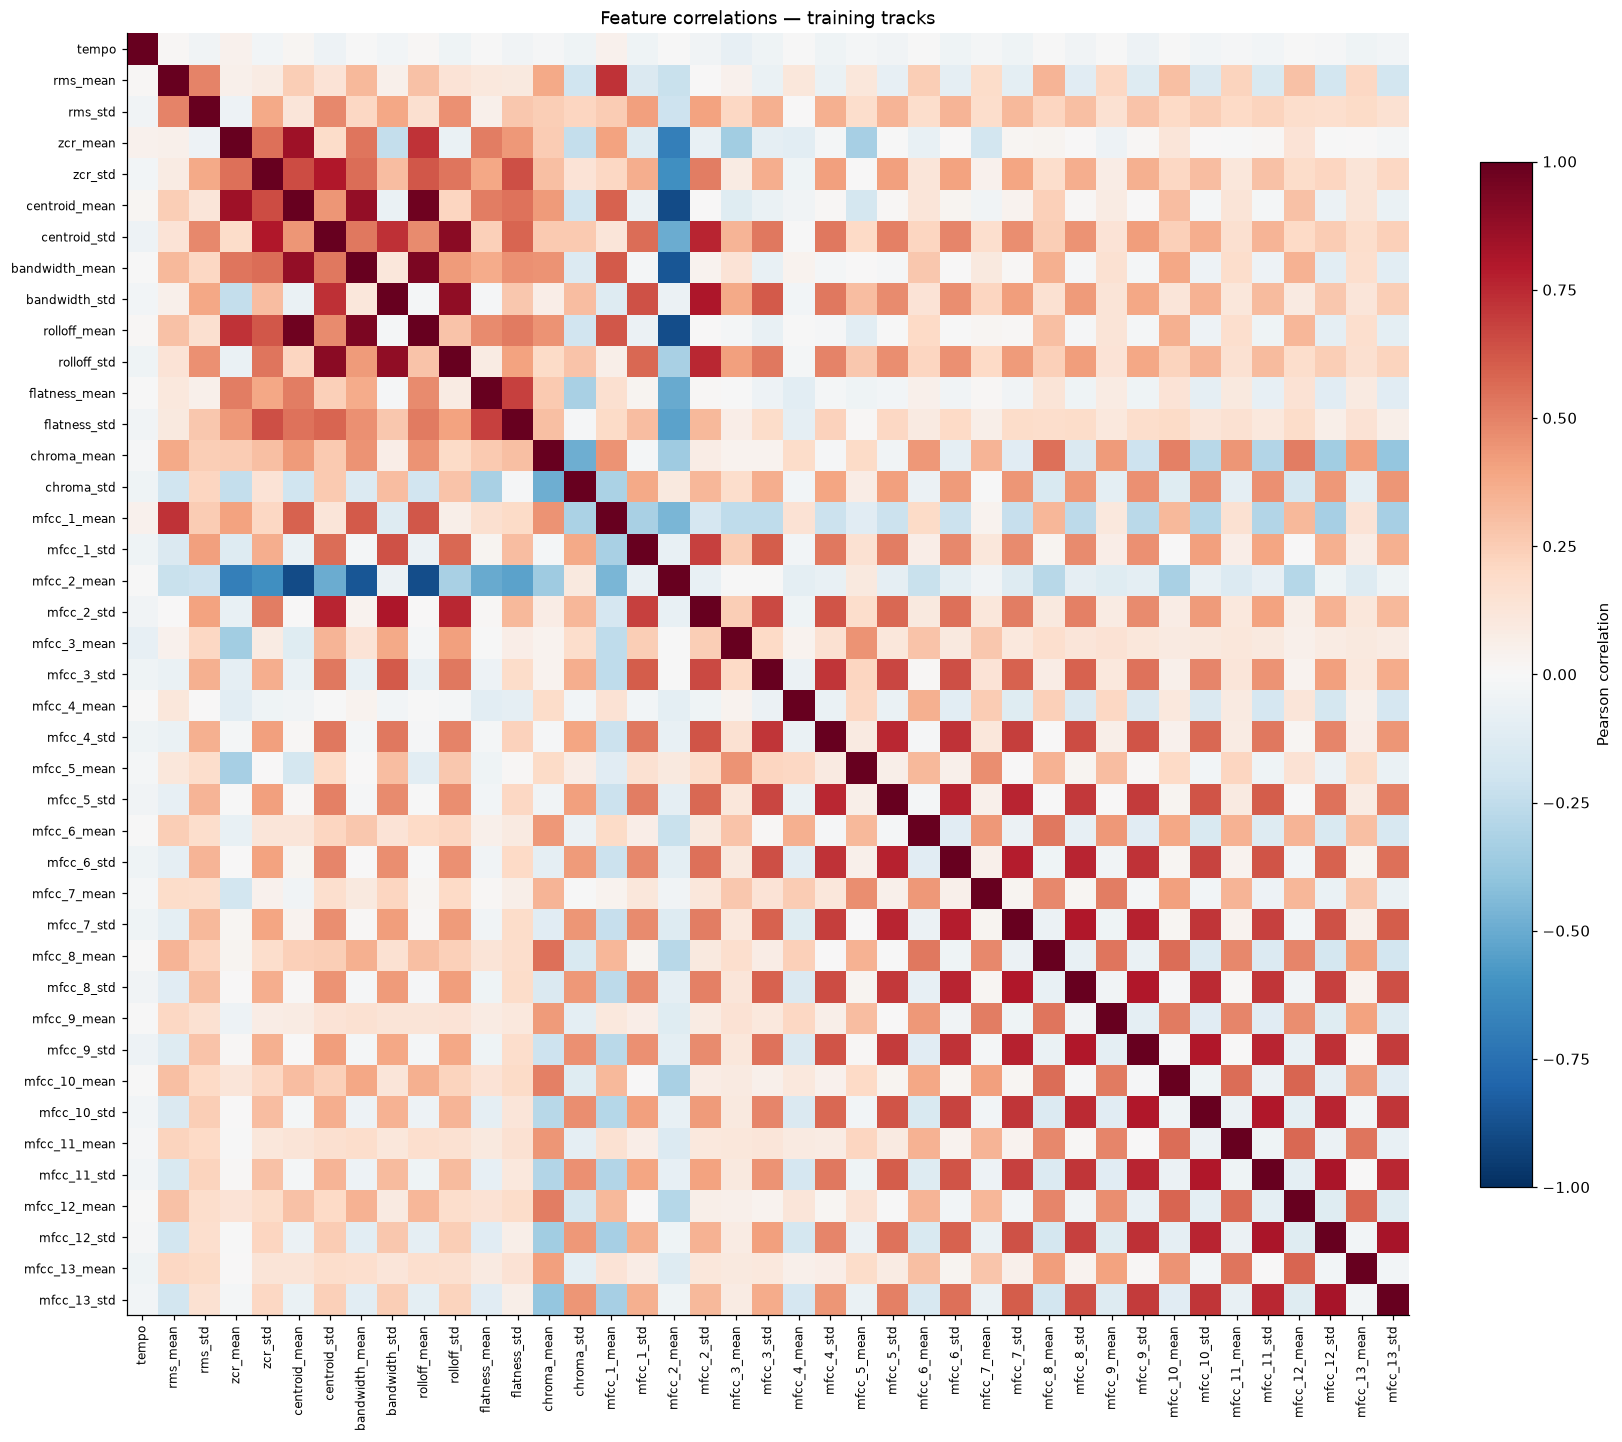

          feature_a     feature_b  correlation  absolute_correlation
214   centroid_mean  rolloff_mean       0.9725                0.9725
296  bandwidth_mean  rolloff_mean       0.9431                0.9431
256    centroid_std   rolloff_std       0.9007                0.9007


In [8]:
variable_features = [name for name in feature_columns if name not in constant_features]
correlation = train[variable_features].corr()
fig, ax = plt.subplots(figsize=(15, 13), constrained_layout=True)
heat = ax.imshow(correlation, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(variable_features)), labels=variable_features, rotation=90, fontsize=8)
ax.set_yticks(range(len(variable_features)), labels=variable_features, fontsize=8)
ax.set_title("Feature correlations — training tracks")
fig.colorbar(heat, ax=ax, shrink=0.8, label="Pearson correlation")
save_plot(fig, "feature_correlations.png")

upper_triangle = np.triu(np.ones(correlation.shape, dtype=bool), k=1)
pairs = correlation.where(upper_triangle).stack().rename("correlation").reset_index()
pairs.columns = ["feature_a", "feature_b", "correlation"]
pairs["absolute_correlation"] = pairs.correlation.abs()
strong_pairs = pairs.loc[pairs.absolute_correlation.ge(0.90)].sort_values("absolute_correlation", ascending=False)
show_table(strong_pairs.round(4))


## 6. Save a short report and decide what to do next
Figures and the report are written to `outputs/eda/`. Rerunning replaces those
analysis outputs. The original feature and audit files remain the inputs.
Use these findings to formulate hypotheses about genre differences. Next, build
a baseline classifier using the existing splits, choose settings on validation,
and evaluate once on the test set after the choices are settled.

In [9]:
report = [
    "# Feature exploration report", "",
    "Sources: outputs/features.csv, outputs/dataset_audit.csv, and outputs/extraction_errors.csv (if present).",
    "",
    f"- Extracted tracks: {len(features):,}; failed tracks: {len(errors)}.",
    f"- Audio features: {len(feature_columns)}; missing cells: {checks['Missing cells']}; infinite values: {checks['Infinite feature values']}.",
    f"- Training tracks used for feature exploration: {len(train):,}.",
    "- All integrity checks passed; every missing attempted track is accounted for in the error log.",
    "", "## Track counts", "", "```", split_counts.to_string(), "```",
    "", "## Failed tracks", "", "```", failure_details.to_string(index=False), "```",
    "", "## Largest differences in genre means", "",
    "Eta-squared is a descriptive training-set association, not predictive accuracy.",
    "", "```", ranking.head(15).round(4).to_string(), "```",
    "", "## Strong feature correlations", "",
    "Pairs with absolute Pearson correlation >= 0.90; training tracks only.",
    "", "```", strong_pairs.round(4).to_string(index=False), "```",
    "", "## Interpretation and next step", "",
    "Compare the boxplots for both median differences and overlap. Review correlated pairs before deciding whether to remove features.",
    "Train a baseline with preprocessing fitted only on training data; use validation for model choices and reserve test for final evaluation.",
    "These observations describe this dataset and extraction method; they do not establish universal properties of genres.",
]
report_path = OUTPUT_DIR / "summary.md"
report_path.write_text("\n".join(report) + "\n", encoding="utf-8")
print(f"Saved report and four figures to: {OUTPUT_DIR}")
print("Next: a standardized logistic-regression baseline, with validation macro F1 and a confusion matrix.")


Saved report and four figures to: C:\Users\Robben's Laptop\OneDrive\Documents\Personal Projects\signals-of-genres\outputs\eda
Next: a standardized logistic-regression baseline, with validation macro F1 and a confusion matrix.
